In [62]:
import pandas as pd

In [63]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/CyberBullying/202305_CYBERBYSTANDER (CYBY23) dataset.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
df = pd.read_excel(file_path)

In [65]:
df.head()
df.columns

Index(['Session', 'user', 'user_id', 'tweet_id', 'reply_id', 'created_at',
       'retweet_count', 'favorite_count', 'text', 'media_url', 'Insult',
       'Threat', 'Identity_Attack', 'Profanity', 'Toxicity', 'Severe_Toxicity',
       'polarity', 'subjectivity', 'sentiment', 'Class label',
       'Bystander Roles Label'],
      dtype='object')

In [66]:
# 1. Forward fill session labels
df["Session"] = df["Session"].ffill()

# 2. Keep only real participant rows
df = df[df["user"].notna()].reset_index(drop=True)

# 3. (Optional) Ensure integer sessions
df["Session"] = df["Session"].astype(int)

df[df["Session"] == 1]


,Session,user,user_id,tweet_id,reply_id,created_at,retweet_count,favorite_count,text,media_url,...,Threat,Identity_Attack,Profanity,Toxicity,Severe_Toxicity,polarity,subjectivity,sentiment,Class label,Bystander Roles Label
0,1,jayneb64,jayneb64,1.622371e+18,1.622371e+18,2023-02-05 23:06:43+00:00,6.0,45.0,Fuck this horrendous woman #Supertanskii tryin...,['https://t.co/MziYDmD91w'],...,0.007288,0.067497,0.018529,0.255384,0.004730,-0.293750,0.550000,negative,2.0,NaN
1,1,robinsonmsr10,robinsonmsr10,1.622955e+18,1.622371e+18,2023-02-07 13:47:19+00:00,0.0,0.0,@jayneb64 @ABaczk @Baddiel Baddiel rightfully ...,[],...,0.007625,0.082528,0.020920,0.235235,0.004215,0.258333,0.333333,positive,NaN,This person agree with the main post
2,1,GerardO14401690,GerardO14401690,1.622784e+18,1.622371e+18,2023-02-07 02:27:52+00:00,0.0,1.0,@jayneb64 @All_left_behind She's a serial liar...,[],...,0.010085,0.058402,0.176599,0.521400,0.020515,-0.200000,0.350000,negative,NaN,This person agree with the main post
3,1,Grombags,Grombags,1.622769e+18,1.622371e+18,2023-02-07 01:26:17+00:00,1.0,3.0,@jayneb64 @All_left_behind She is completely d...,[],...,0.012648,0.074256,0.122868,0.377512,0.016836,0.178571,0.485714,positive,NaN,This person agree with the main post
4,1,ladywal99943295,ladywal99943295,1.622696e+18,1.622371e+18,2023-02-06 20:37:31+00:00,1.0,2.0,@jayneb64 Yes. I queried her support for Baddi...,[],...,0.007703,0.002793,0.016548,0.053295,0.001554,0.100000,1.000000,positive,NaN,This person agree with the main post
5,1,ABaczk,ABaczk,1.622375e+18,1.622371e+18,2023-02-05 23:21:42+00:00,0.0,1.0,"@jayneb64 sorry, which baddiel is that and wha...",[],...,0.008117,0.005550,0.020852,0.042162,0.001774,-0.500000,1.000000,negative,NaN,This person is not taking any sides


Define a function to assign bystander roles

In [67]:
def assign_bystander_role(text):
    if pd.isna(text):
        return None

    text = text.lower().strip()

    # Defender: disagrees with the main post
    if "disagree" in text and "main post" in text:
        return "Defender"

    # Instigator: agrees with the main post
    elif "agree" in text and "main post" in text:
        return "Instigator"

    # Impartial: not taking any sides
    elif "not taking any sides" in text:
        return "Impartial"

    # Other: unrelated replies (e.g. Advertisement)
    elif "unrelated replies" in text or "advertisement" in text:
        return "Other"

    else:
        return "Unknown"


Apply the role-classification function

In [68]:
df["Bystander_Role"] = df["Bystander Roles Label"].apply(assign_bystander_role)

#Distribution of bystander roles across all sessions

Check overall role counts

In [69]:
df["Bystander_Role"].value_counts()


,count
Bystander_Role,
Instigator,228
Impartial,191
Defender,96
Other,9


Count total participants per session

In [47]:
participants_per_session = (
    df.groupby("Session")
      .size()
      .reset_index(name="Total_Participants")
)

Count bystander roles per session

In [48]:
role_counts_per_session = (
    df.groupby(["Session", "Bystander_Role"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)


In [49]:
session_summary = participants_per_session.merge(
    role_counts_per_session, on="Session"
)

In [50]:
session_summary


,Session,Total_Participants,Defender,Impartial,Instigator,Other
0,1,6,0,1,4,0
1,2,3,0,1,1,0
2,3,5,1,1,2,0
3,4,8,6,0,0,1
4,5,3,0,0,2,0
...,...,...,...,...,...,...
107,108,6,3,2,0,0
108,109,10,0,9,0,0
109,110,3,2,0,0,0
110,111,10,0,7,2,0


Compute the total number of bystanders per session

In [51]:
session_summary["Total_Bystanders"] = (
    session_summary["Total_Participants"] - 1
)
assert (session_summary["Total_Bystanders"] > 0).all(), \
    "Some sessions have no bystanders"


This step calculates the total number of bystanders in each session by subtracting the original post author from the total number of participants.(-1) An assertion check is included to ensure that every session contains at least one bystander.

Define bystander role categories

In [52]:
role_cols = ["Defender", "Impartial", "Instigator", "Other"]


Compute session-level role proportions

In [53]:
for col in role_cols:
    session_summary[f"{col}_pct"] = (
        session_summary[col] / session_summary["Total_Bystanders"]
    )

For each session, this step computes the proportion of bystanders belonging to each role by dividing the role count by the total number of bystanders in that session.

Aggregate bystanders across all sessions

In [54]:
total_bystanders = session_summary["Total_Bystanders"].sum()


This step sums the number of bystanders across all sessions to obtain the total population size used for estimating overall role probabilities.

Calculate the overall distribution of bystander roles

In [55]:
overall_distribution = (
    session_summary[role_cols].sum() / total_bystanders
)

overall_distribution

,0
Defender,0.183206
Impartial,0.364504
Instigator,0.435115
Other,0.017176


This step aggregates role counts across all sessions and divides them by the total number of bystanders, producing the overall probability of each bystander role.

Visualise the overall role distribution

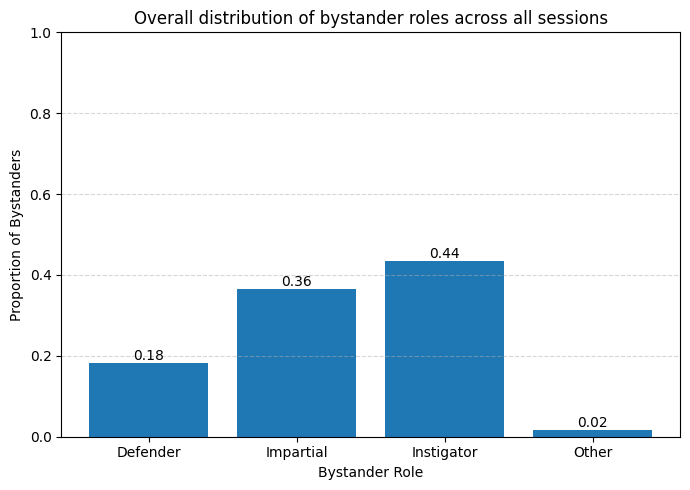

In [56]:
import matplotlib.pyplot as plt
roles = overall_distribution.index
values = overall_distribution.values
plt.figure(figsize=(7, 5))
bars = plt.bar(roles, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.ylim(0, 1)
plt.ylabel("Proportion of Bystanders")
plt.xlabel("Bystander Role")
plt.title("Overall distribution of bystander roles across all sessions")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#“How are bystander roles distributed within each aggression class (0, 1, 2)?”

Count bystander roles within each aggression class

In [72]:
df.groupby(["Class label", "Bystander_Role"])
df["Class label"] = df.groupby("Session")["Class label"].ffill()
df = df[
    df["Bystander_Role"].notna() &
    (df["Bystander_Role"] != "Unknown")
]
role_counts_by_class = (
    df
        .groupby(["Class label", "Bystander_Role"])
        .size()
        .unstack(fill_value=0)
)

role_counts_by_class


Bystander_Role,Defender,Impartial,Instigator,Other
Class label,,,,
0.0,32,98,100,7
1.0,55,60,99,2
2.0,9,33,29,0


Convert counts → proportions (distribution)

In [73]:
role_distribution_by_class = (
    role_counts_by_class
        .div(role_counts_by_class.sum(axis=1), axis=0)
)

role_distribution_by_class


Bystander_Role,Defender,Impartial,Instigator,Other
Class label,,,,
0.0,0.135021,0.413502,0.421941,0.029536
1.0,0.254630,0.277778,0.458333,0.009259
2.0,0.126761,0.464789,0.408451,0.000000


Visualization

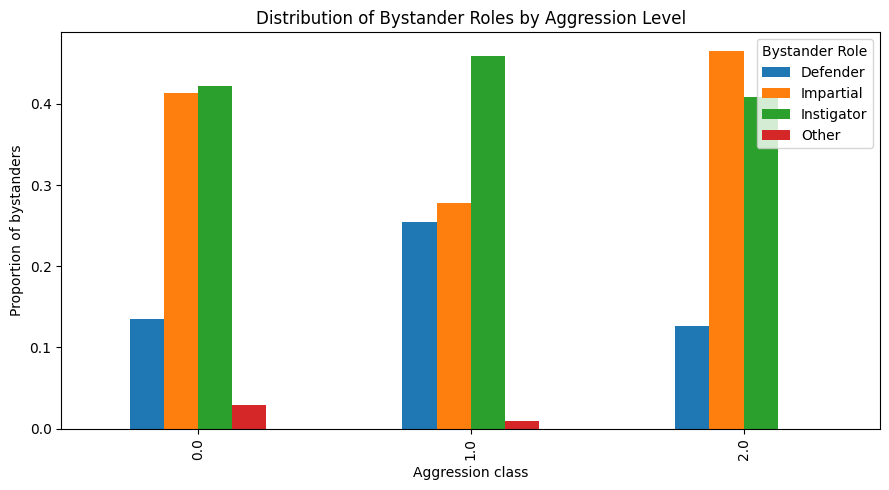

In [74]:
import matplotlib.pyplot as plt

role_distribution_by_class.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Proportion of bystanders")
plt.xlabel("Aggression class")
plt.title("Distribution of Bystander Roles by Aggression Level")
plt.legend(title="Bystander Role")
plt.tight_layout()
plt.show()


Class label = prsent the level of aggression of the whole thread by
 three-point scale (0-1-2).

 0 - aggression
 1 - bullying with low aggression
 2 - bullying with high aggression

# Distribution of 'Insult', 'Threat', 'Identity_Attack', 'Profanity', 'Toxicity', 'Severe_Toxicity', 'polarity', 'subjectivity'

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

vars_to_check = [
    'Insult',
    'Threat',
    'Identity_Attack',
    'Profanity',
    'Toxicity',
    'Severe_Toxicity',
    'polarity',
    'subjectivity'
]


Basic distribution summary

In [20]:
df[vars_to_check].describe()

,Insult,Threat,Identity_Attack,Profanity,Toxicity,Severe_Toxicity,polarity,subjectivity
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,0.197216,0.042058,0.081998,0.226257,0.284171,0.079822,0.034106,0.392347
std,0.254130,0.100026,0.143968,0.295631,0.294254,0.151405,0.324571,0.337576
min,0.005793,0.005387,0.000495,0.010075,0.003487,0.000529,-1.000000,0.000000
25%,0.015645,0.007366,0.004435,0.021860,0.040307,0.002267,-0.062031,0.000000
50%,0.049985,0.009619,0.010322,0.057945,0.160155,0.005341,0.000000,0.435417
75%,0.367091,0.016163,0.082528,0.340636,0.471199,0.025419,0.200000,0.600000
max,0.913728,0.728332,0.789590,0.954033,0.981763,0.661228,1.000000,1.000000


Histograms (distribution shape)

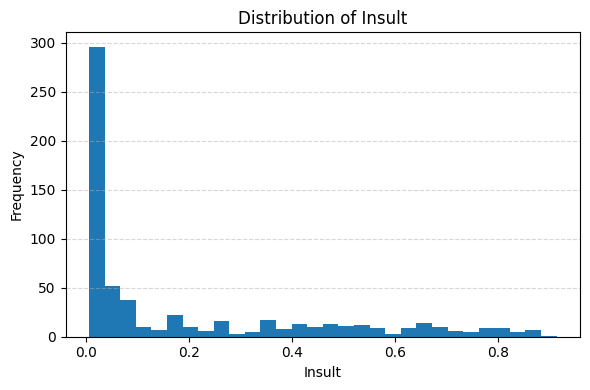

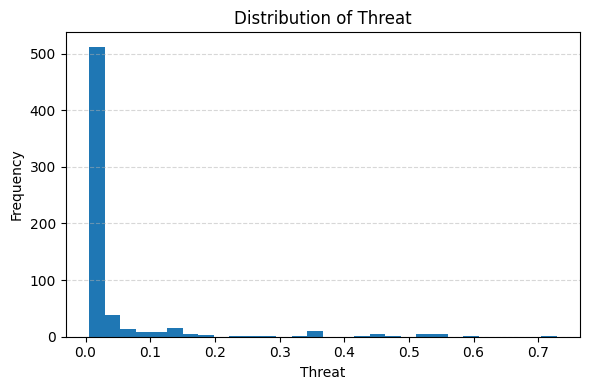

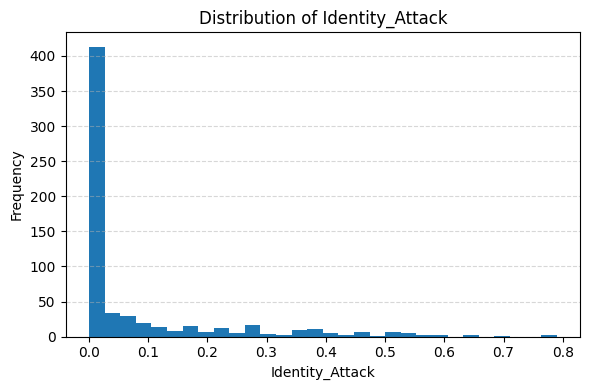

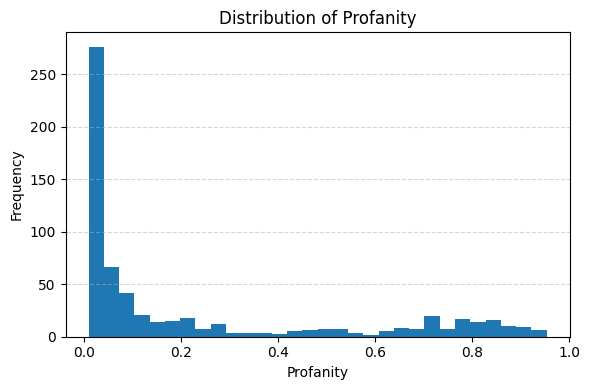

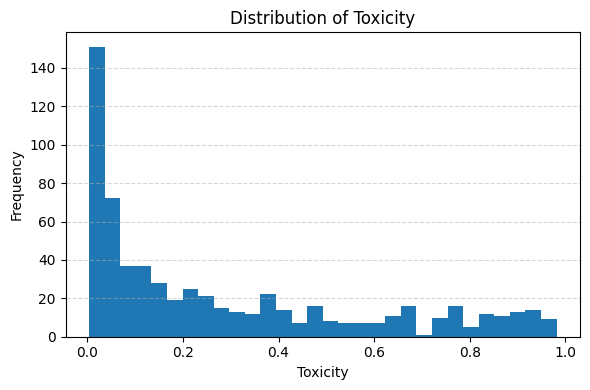

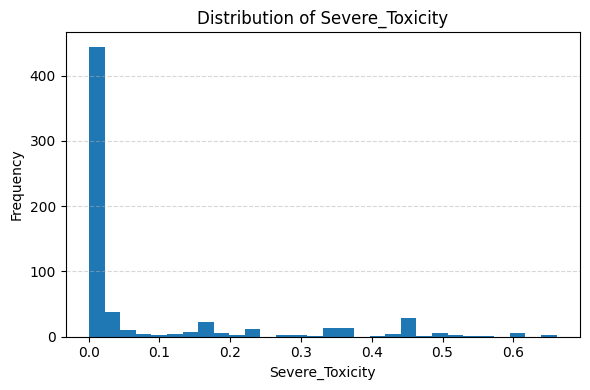

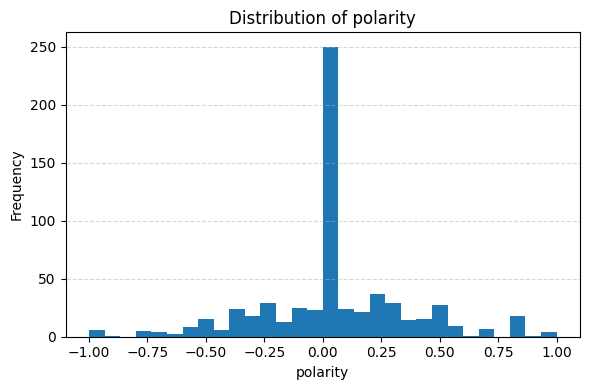

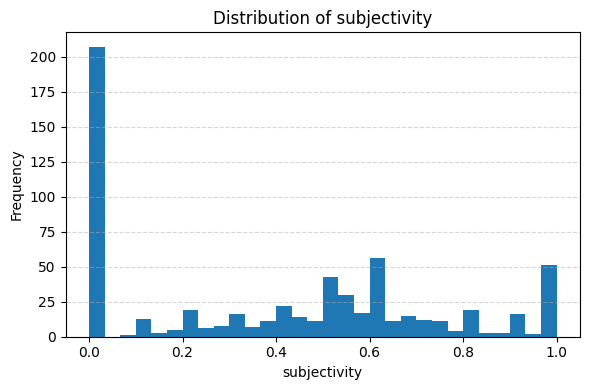

In [18]:
for col in vars_to_check:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


Boxplots (outliers & spread)

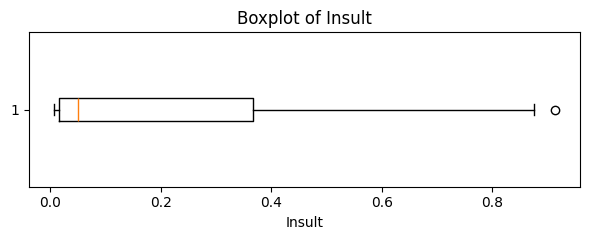

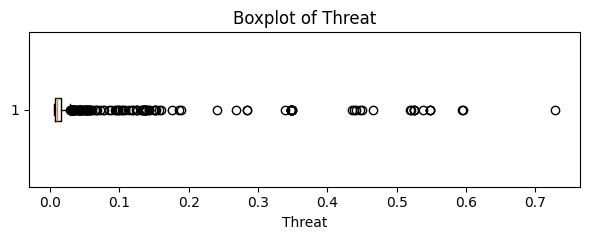

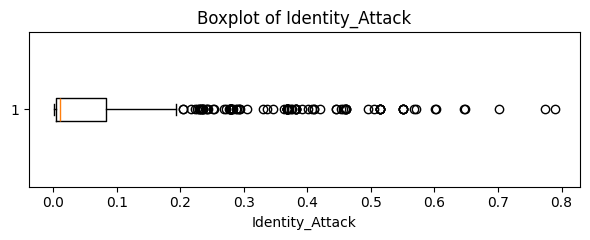

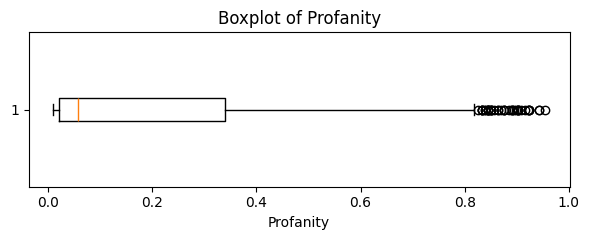

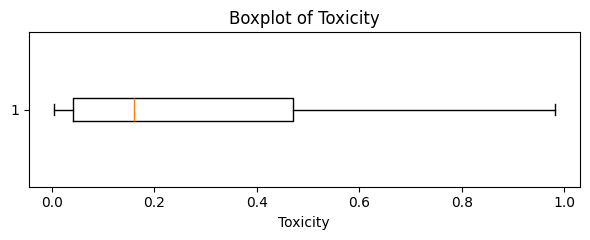

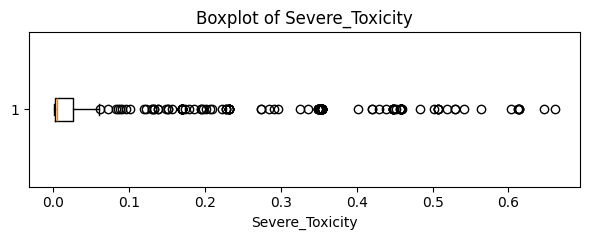

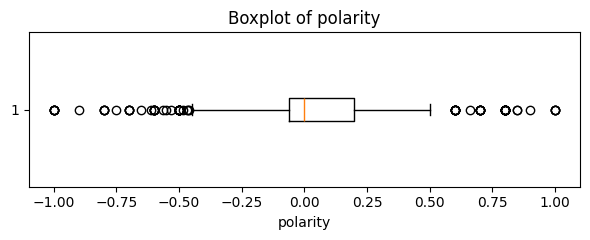

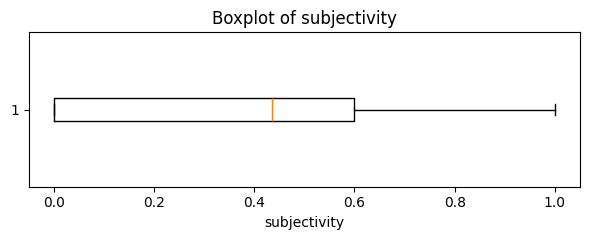

In [19]:
for col in vars_to_check:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()
